In [4]:
import pandas as pd

df = pd.read_csv('../Data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,"Harley Himber, Crystal Latapie, Juicy, Jamie, ...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape

(8807, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7983 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             824
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
# Fill missing values in text columns with "Unknown"
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Drop rows where date_added, rating, or duration is missing (very few rows)
df = df.dropna(subset=['date_added', 'rating', 'duration'])

# Confirm no more missing values
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [10]:
df.shape

(8790, 12)

In [11]:
df['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [12]:
df['type'].value_counts(normalize=True) * 100

type
Movie      69.692833
TV Show    30.307167
Name: proportion, dtype: float64

In [13]:
# Split the comma-separated genres and count each one individually
genres = df['listed_in'].str.split(', ').explode()
genres.value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [14]:
countries = df['country'].str.split(', ').explode()
countries.value_counts().head(10)

country
United States     3680
India             1046
Unknown            829
United Kingdom     803
Canada             445
France             393
Japan              316
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

In [15]:
df['rating'].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [16]:
# Convert date_added to proper date format, then extract the year
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

df['year_added'].value_counts().sort_index()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     415
2017.0    1161
2018.0    1624
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

In [17]:
# Filter only movies, then extract the number from duration (e.g., "90 min" -> 90)
movies = df[df['type'] == 'Movie'].copy()
movies['duration_minutes'] = movies['duration'].str.replace(' min', '').astype(int)

movies['duration_minutes'].describe()

count    6126.000000
mean       99.584884
std        28.283225
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

In [18]:
# Filter only TV shows, then extract the number of seasons (e.g., "2 Seasons" -> 2)
tv_shows = df[df['type'] == 'TV Show'].copy()
tv_shows['num_seasons'] = tv_shows['duration'].str.replace(' Season', '').str.replace('s', '').astype(int)

tv_shows['num_seasons'].describe()

count    2664.000000
mean        1.751877
std         1.550622
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: num_seasons, dtype: float64

In [21]:
df.to_csv('../data/netflix_cleaned.csv', index=False)

C:\Users\welcome\AppData\Local\Temp\ipykernel_3932\2988046843.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette=['#E50914', '#221f1f'])


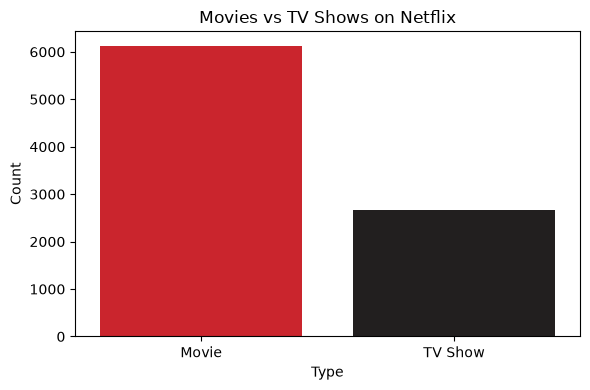

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../images', exist_ok=True)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type', palette=['#E50914', '#221f1f'])
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../images/movies_vs_tvshows.png', dpi=150)
plt.show()

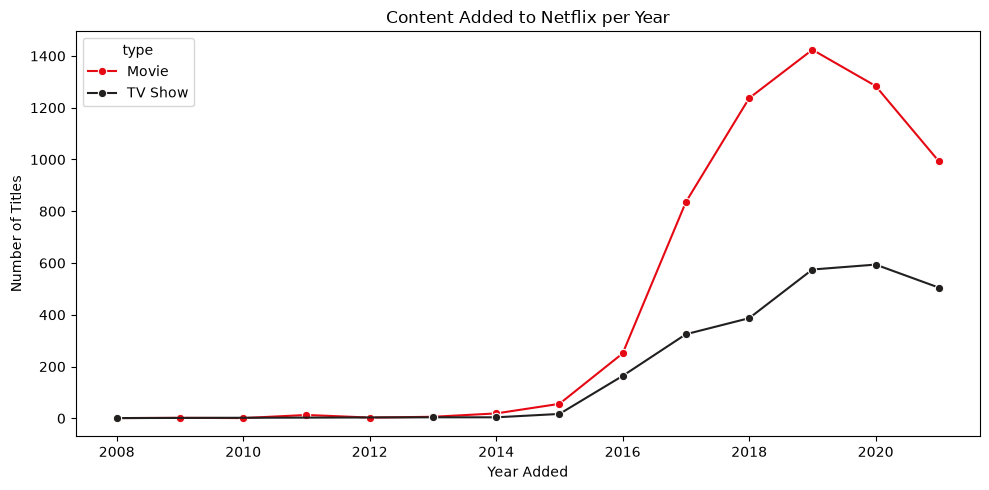

In [23]:
yearly = df.groupby(['year_added', 'type']).size().reset_index(name='count')

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly, x='year_added', y='count', hue='type',
             palette=['#E50914', '#221f1f'], marker='o')
plt.title('Content Added to Netflix per Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.savefig('../images/content_added_per_year.png', dpi=150)
plt.show()

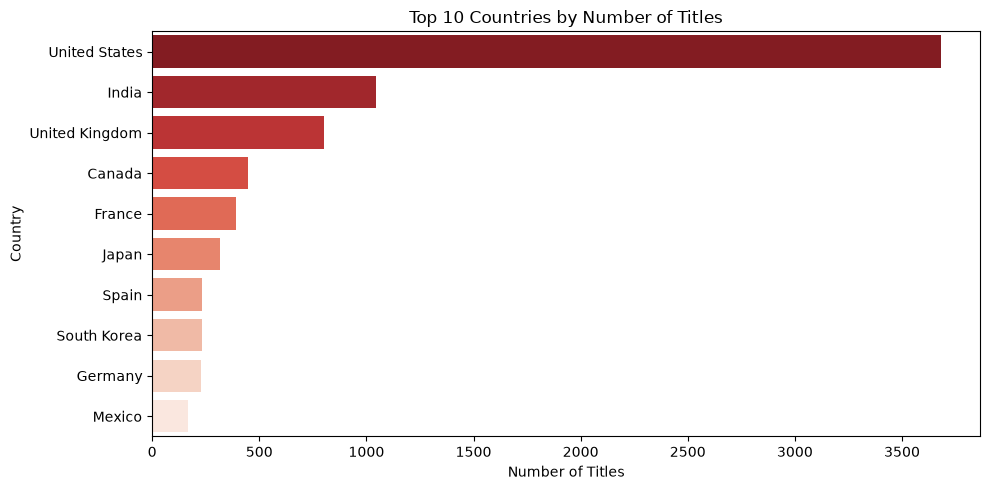

In [24]:
countries = df[df['country'] != 'Unknown']['country'].str.split(', ').explode()
top_countries = countries.value_counts().head(10).reset_index()
top_countries.columns = ['country', 'count']

plt.figure(figsize=(10, 5))
sns.barplot(data=top_countries, x='count', y='country',
            hue='country', palette='Reds_r', legend=False)
plt.title('Top 10 Countries by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('../images/top_10_countries.png', dpi=150)
plt.show()

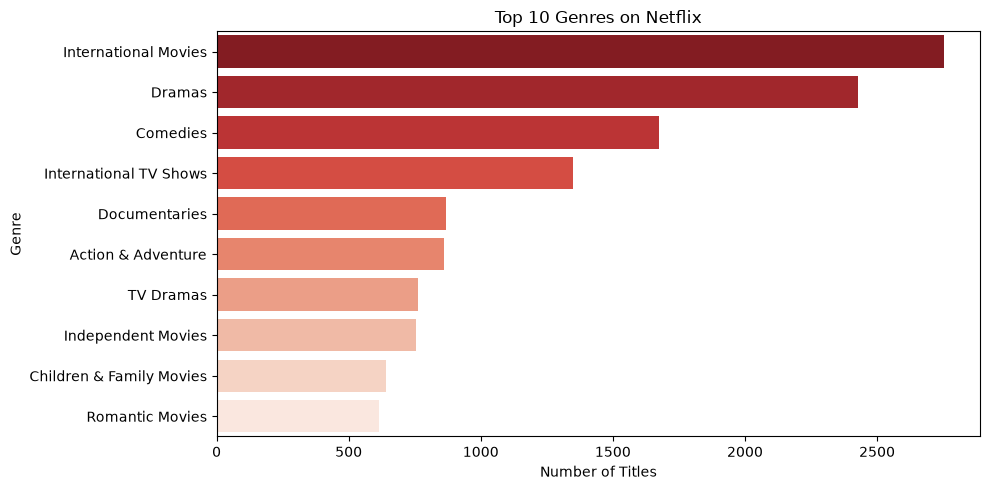

In [25]:
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10).reset_index()
top_genres.columns = ['genre', 'count']

plt.figure(figsize=(10, 5))
sns.barplot(data=top_genres, x='count', y='genre',
            hue='genre', palette='Reds_r', legend=False)
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('../images/top_10_genres.png', dpi=150)
plt.show()

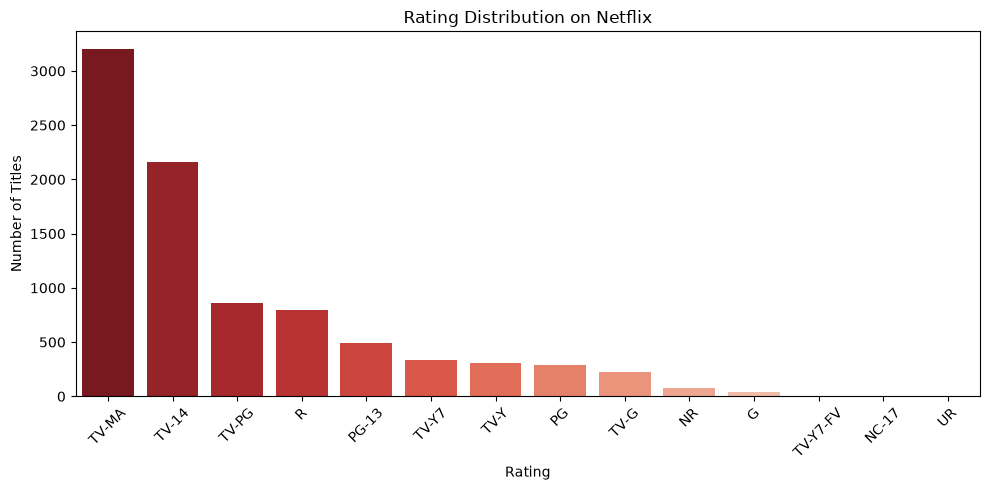

In [26]:
rating_counts = df['rating'].value_counts().reset_index()
rating_counts.columns = ['rating', 'count']

plt.figure(figsize=(10, 5))
sns.barplot(data=rating_counts, x='rating', y='count',
            hue='rating', palette='Reds_r', legend=False)
plt.title('Rating Distribution on Netflix')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/rating_distribution.png', dpi=150)
plt.show()

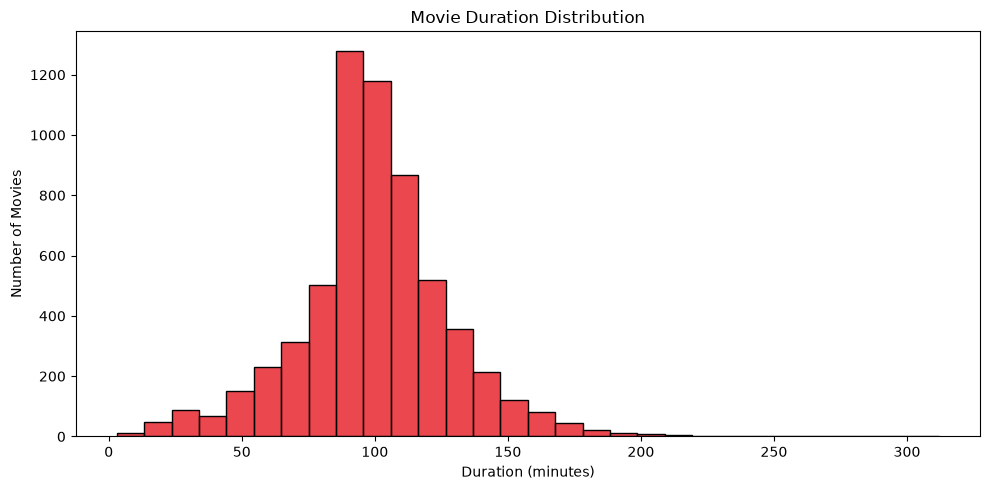

In [27]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.extract(r'(\d+)').astype(float)

plt.figure(figsize=(10, 5))
sns.histplot(data=movies, x='duration_min', bins=30, color='#E50914')
plt.title('Movie Duration Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('../images/movie_duration.png', dpi=150)
plt.show()